In [ ]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Librerías listas para usarse.")

Librerías listas para usarse.


In [7]:
# Leer el archivo CSV
df = pd.read_csv('adult.csv')

print("¡Datos cargados correctamente!")

¡Datos cargados correctamente!


In [40]:
# Reemplazar '?' por NaN y revisar nulos
df = df.replace(['?', ' ?'], np.nan)

print("Tamaño original:", df.shape)
display(df.isna().sum().sort_values(ascending=False).head(10))

# Para simplificar la práctica, se eliminan filas incompletas
df = df.dropna().reset_index(drop=True)
print("Tamaño tras dropna:", df.shape)

df.head()

Tamaño original: (30162, 15)


Age               0
Workclass         0
fnlwgt            0
Education         0
Education-Num     0
Marital-status    0
Ocupation         0
Relationship      0
Race              0
Sex               0
dtype: int64

Tamaño tras dropna: (30162, 15)


,Age,Workclass,fnlwgt,Education,Education-Num,Marital-status,Ocupation,Relationship,Race,Sex,Capital-gain,Capital-loss,Hours-per-week,Native-country,Makes over a year
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [17]:
df.dtypes

Age                   int64
Workclass            object
fnlwgt                int64
Education            object
Education-Num         int64
Marital-status       object
Ocupation            object
Relationship         object
Race                 object
Sex                  object
Capital-gain          int64
Capital-loss          int64
Hours-per-week        int64
Native-country       object
Makes over a year    object
dtype: object

In [18]:

# =========================
# ACTIVIDAD: ajustar clasificación teórica
# =========================

tipos = {
    "Age": "Numérico (discreto)",
    "fnlwgt": "Numérico (discreto)",
    "Education-Num": "Numérico (discreto/ordinal aproximado)",
    "Capital-gain": "Numérico (discreto)",
    "Capital-loss": "Numérico (discreto)",
    "Hours-per-week": "Numérico (discreto)",

    "Workclass": "Nominal",
    "Education": "Nominal (o Ordinal si se define un orden)",
    "Marital-status": "Nominal",
    "Ocupation": "Nominal", # Corregido a 'Ocupation' con una C
    "Relationship": "Nominal",
    "Race": "Nominal",
    "Native-country": "Nominal",

    "Sex": "Binario",
    "Makes over a year": "Binario" # Corregido de 'Income' a 'Makes over a year'
}

tabla_tipos = pd.DataFrame({
    "Atributo": list(tipos.keys()),
    "Tipo_teorico": list(tipos.values()),
    "dtype_pandas": [df[c].dtype for c in tipos.keys()],
    "Valores_unicos": [df[c].nunique() for c in tipos.keys()]
}).sort_values("Atributo")

tabla_tipos

,Atributo,Tipo_teorico,dtype_pandas,Valores_unicos
0,Age,Numérico (discreto),int64,72
3,Capital-gain,Numérico (discreto),int64,118
4,Capital-loss,Numérico (discreto),int64,90
7,Education,Nominal (o Ordinal si se define un orden),object,16
2,Education-Num,Numérico (discreto/ordinal aproximado),int64,16
5,Hours-per-week,Numérico (discreto),int64,94
14,Makes over a year,Binario,object,2
8,Marital-status,Nominal,object,7
12,Native-country,Nominal,object,41
9,Ocupation,Nominal,object,14


In [19]:
df.describe()

,Age,fnlwgt,Education-Num,Capital-gain,Capital-loss,Hours-per-week
count,30162.000000,3.016200e+04,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1.897938e+05,10.121312,1092.007858,88.372489,40.931238
std,13.134665,1.056530e+05,2.549995,7406.346497,404.298370,11.979984
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.176272e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.784250e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376285e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [20]:
# =========================
# ACTIVIDAD: tendencia central
# =========================

for col in ["Age", "Hours-per-week"]:
    media = df[col].mean()
    mediana = df[col].median()
    moda = df[col].mode().iloc[0]
    
    print(f"{col:>15} | media={media:.3f} | mediana={mediana:.3f} | moda={moda}")

            Age | media=38.438 | mediana=37.000 | moda=36
 Hours-per-week | media=40.931 | mediana=40.000 | moda=40


In [21]:
# =========================
# ACTIVIDAD: dispersión
# =========================

col = "Hours-per-week"

rango = df[col].max() - df[col].min()
q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1
var = df[col].var()
std = df[col].std()

print("Variable:", col)
print("Rango:", rango)
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Varianza:", var)
print("Desv. estándar:", std)

Variable: Hours-per-week
Rango: 98
Q1: 40.0
Q3: 45.0
IQR: 5.0
Varianza: 143.52002213363653
Desv. estándar: 11.979984229273281


In [22]:
# =========================
# ACTIVIDAD: frecuencias
# =========================

for col in ["Ocupation", "Native-country"]:
    print("\nTop 10 de:", col)
    display(df[col].value_counts().head(10))


Top 10 de: Ocupation


Ocupation
Prof-specialty       4038
Craft-repair         4030
Exec-managerial      3992
Adm-clerical         3721
Sales                3584
Other-service        3212
Machine-op-inspct    1966
Transport-moving     1572
Handlers-cleaners    1350
Farming-fishing       989
Name: count, dtype: int64


Top 10 de: Native-country


Native-country
United-States    27504
Mexico             610
Philippines        188
Germany            128
Puerto-Rico        109
Canada             107
El-Salvador        100
India              100
Cuba                92
England             86
Name: count, dtype: int64

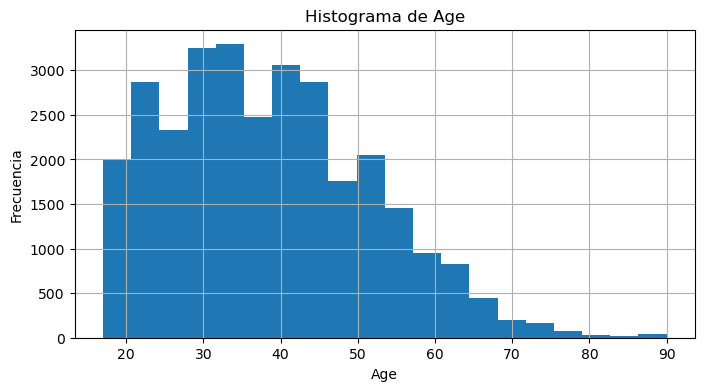

In [23]:
# 6.1 Histograma
df["Age"].hist(bins=20)
plt.title("Histograma de Age")
plt.xlabel("Age")
plt.ylabel("Frecuencia")
plt.show()

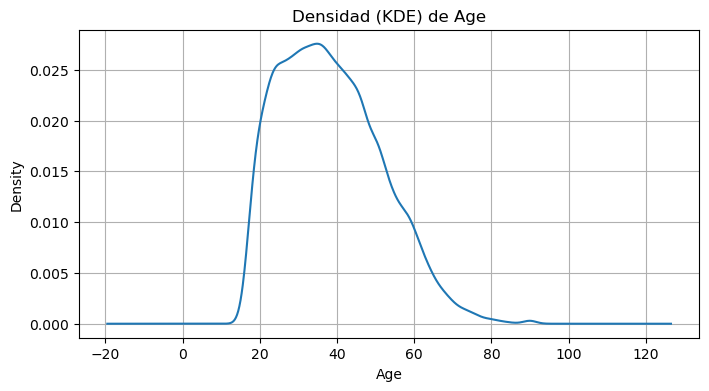

In [24]:
# 6.2 Densidad (KDE)
df["Age"].plot.kde()
plt.title("Densidad (KDE) de Age")
plt.xlabel("Age")
plt.show()

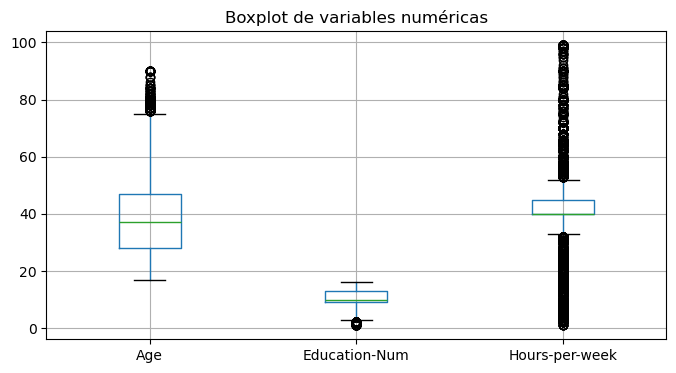

In [25]:
# 6.3 Boxplot
df.boxplot(column=["Age", "Education-Num", "Hours-per-week"])
plt.title("Boxplot de variables numéricas")
plt.show()

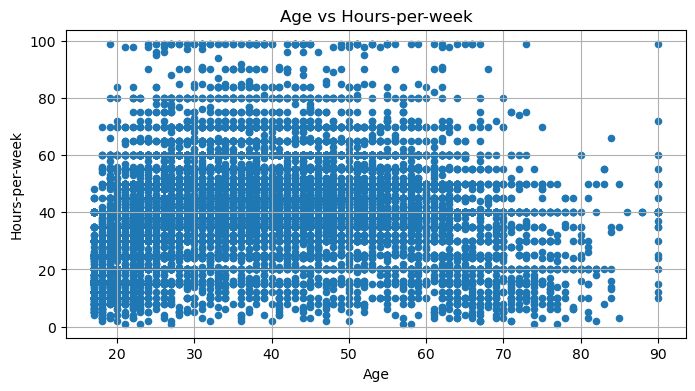

In [26]:
# 6.4 Scatter
df.plot.scatter(x="Age", y="Hours-per-week")
plt.title("Age vs Hours-per-week")
plt.show()

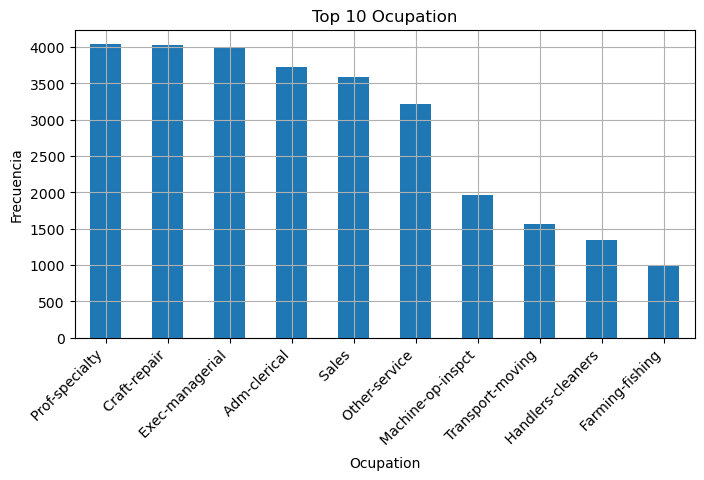

In [27]:
# 6.5 Barras para categóricas (Top 10)
top = df["Ocupation"].value_counts().head(10)
top.plot(kind="bar")
plt.title("Top 10 Ocupation")
plt.xlabel("Ocupation")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")
plt.show()

In [29]:
muestra = df.sample(10, random_state=7).reset_index(drop=True)
muestra[["Age", "Education-Num", "Hours-per-week", "Sex", "Makes over a year", "Ocupation"]]

,Age,Education-Num,Hours-per-week,Sex,Makes over a year,Ocupation
0,40,6,40,Male,<=50K,Transport-moving
1,32,11,40,Male,<=50K,Craft-repair
2,45,13,30,Male,<=50K,Prof-specialty
3,61,9,60,Male,<=50K,Farming-fishing
4,30,10,40,Male,<=50K,Craft-repair
5,37,9,50,Male,>50K,Prof-specialty
6,51,10,15,Female,>50K,Exec-managerial
7,53,12,40,Male,>50K,Exec-managerial
8,45,9,50,Male,<=50K,Exec-managerial
9,26,7,40,Male,>50K,Adm-clerical


In [30]:
# =========================
# ACTIVIDAD: Distancias numéricas (Minkowski)
# p=1: Manhattan
# p=2: Euclidiana
# =========================

def minkowski(a, b, p=2):
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    return np.sum(np.abs(a-b)**p)**(1/p)

num_cols = ["Age", "Education-Num", "Hours-per-week"]

a = muestra.loc[0, num_cols]
b = muestra.loc[1, num_cols]

print("Fila 0:", list(a))
print("Fila 1:", list(b))
print("Manhattan (p=1):", minkowski(a, b, p=1))
print("Euclidiana (p=2):", minkowski(a, b, p=2))

Fila 0: [np.int64(40), np.int64(6), np.int64(40)]
Fila 1: [np.int64(32), np.int64(11), np.int64(40)]
Manhattan (p=1): 13.0
Euclidiana (p=2): 9.433981132056603


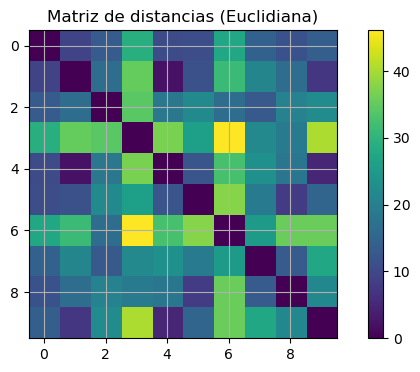

In [31]:
def matriz_distancias_numericas(df_small, cols, p=2):
    X = df_small[cols].to_numpy(dtype=float)
    n = X.shape[0]
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            D[i, j] = minkowski(X[i], X[j], p=p)
    return pd.DataFrame(D)

D_euclid = matriz_distancias_numericas(muestra, num_cols, p=2)
D_euclid

     

plt.imshow(D_euclid.values)
plt.title("Matriz de distancias (Euclidiana)")
plt.colorbar()
plt.show()

In [ ]:
# 1. Selección de columnas y limpieza de nombres
# Cambiamos "Income" por "Makes over a year"
bin_df = muestra[["Sex", "Makes over a year"]].copy()

# 2. Codificación a 0 y 1 (usamos .str.strip() para quitar espacios fantasmas)
bin_df["Sex"] = (bin_df["Sex"].str.strip() == "Male").astype(int)
bin_df["Makes over a year"] = (bin_df["Makes over a year"].str.strip() == ">50K").astype(int)

# Mostramos la tabla transformada
display(bin_df)

Tabla binaria (Muestra):


,Sex,Makes over a year
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0
5,1,1
6,0,1
7,1,1
8,1,0
9,1,1


In [33]:
# 2. Definimos las funciones de distancia
def hamming(a, b):
    a = np.array(a)
    b = np.array(b)
    return np.mean(a != b)

def jaccard(a, b):
    a = np.array(a)
    b = np.array(b)
    inter = np.sum((a == 1) & (b == 1))
    union = np.sum((a == 1) | (b == 1))
    return 1 - (0 if union == 0 else inter / union) # Se suele usar 1 - similitud para que sea distancia

# 3. Calculamos y mostramos resultados
h = hamming(bin_df.loc[0], bin_df.loc[1])
j = jaccard(bin_df.loc[0], bin_df.loc[1])

print(f"Distancia Hamming (0 vs 1): {h}")
print(f"Distancia Jaccard (0 vs 1): {j}")

Distancia Hamming (0 vs 1): 0.0
Distancia Jaccard (0 vs 1): 0.0


In [35]:
# =========================
# ACTIVIDAD: Similitud de Coseno con Estandarización
# =========================

# 1. Preparar y estandarizar datos (Z-score)
X = muestra[num_cols].to_numpy(dtype=float)
# Estandarización manual: (valor - media) / desviación estándar
Xz = (X - X.mean(axis=0)) / X.std(axis=0)

# 2. Definir función de similitud de Coseno
def cosine_sim(u, v):
    u = np.array(u, dtype=float)
    v = np.array(v, dtype=float)
    denom = (np.linalg.norm(u) * np.linalg.norm(v))
    return 0 if denom == 0 else float(np.dot(u, v) / denom)

# 3. Generar la matriz de similitud
n = Xz.shape[0]
S = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        S[i, j] = cosine_sim(Xz[i], Xz[j])

# 4. Mostrar tabla y gráfica
S_df = pd.DataFrame(S)
display(S_df)

,0,1,2,3,4,5,6,7,8,9
0,1.000000,-0.501979,-0.869494,0.026400,-0.066358,0.327363,-0.098273,-0.816779,0.267307,0.725199
1,-0.501979,1.000000,0.413940,-0.678615,0.896153,0.175662,-0.204960,-0.084210,-0.472600,0.230710
2,-0.869494,0.413940,1.000000,-0.317776,0.023130,-0.718707,0.562062,0.764356,-0.656588,-0.665609
3,0.026400,-0.678615,-0.317776,1.000000,-0.758145,0.254698,-0.383282,0.367200,0.870185,-0.487698
4,-0.066358,0.896153,0.023130,-0.758145,1.000000,0.385409,-0.303347,-0.517267,-0.392783,0.638523
5,0.327363,0.175662,-0.718707,0.254698,0.385409,1.000000,-0.964664,-0.560455,0.690330,0.537590
6,-0.098273,-0.204960,0.562062,-0.383282,-0.303347,-0.964664,1.000000,0.324004,-0.748431,-0.306493
7,-0.816779,-0.084210,0.764356,0.367200,-0.517267,-0.560455,0.324004,1.000000,-0.064878,-0.988043
8,0.267307,-0.472600,-0.656588,0.870185,-0.392783,0.690330,-0.748431,-0.064878,1.000000,-0.044620
9,0.725199,0.230710,-0.665609,-0.487698,0.638523,0.537590,-0.306493,-0.988043,-0.044620,1.000000


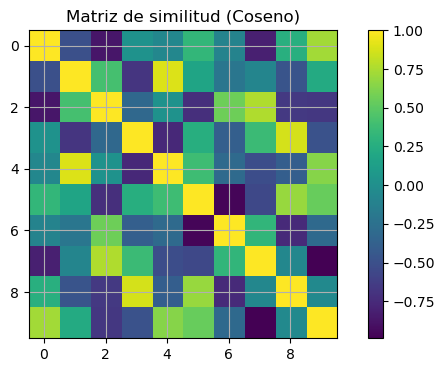

In [36]:
plt.imshow(S_df.values, cmap='viridis') # Agregué un mapa de color para que se vea más claro
plt.title("Matriz de similitud (Coseno)")
plt.colorbar()
plt.show()

In [37]:
# =========================
# ACTIVIDAD: Distancia de Gower (Híbrida)
# =========================

num_cols = ["Age", "Education-Num", "Hours-per-week"]
# Corregimos "Occupation" a "Ocupation" para tu dataset
cat_cols = ["Workclass", "Marital-status", "Ocupation", "Race", "Sex"]

# Tomamos una muestra nueva de 10 personas
m = df.sample(10, random_state=3).reset_index(drop=True)

# Calculamos los rangos para normalizar las numéricas
ranges = {c: (df[c].max() - df[c].min()) for c in num_cols}

def gower_like(row_a, row_b):
    # --- Parte 1: Numéricas (Distancia normalizada) ---
    dn = 0
    for c in num_cols:
        r = ranges[c] if ranges[c] != 0 else 1
        dn += abs(row_a[c] - row_b[c]) / r
    dn /= len(num_cols)

    # --- Parte 2: Categóricas (Distancia de coincidencia) ---
    dc = 0
    for c in cat_cols:
        # Usamos strip() por si hay espacios en blanco en los textos
        val_a = str(row_a[c]).strip()
        val_b = str(row_b[c]).strip()
        dc += 0 if val_a == val_b else 1
    dc /= len(cat_cols)

    # Promedio de ambas distancias
    return (dn + dc) / 2

# Generamos la matriz
n = len(m)
Dmix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        Dmix[i, j] = gower_like(m.loc[i], m.loc[j])

Dmix_df = pd.DataFrame(Dmix)
display(Dmix_df)

,0,1,2,3,4,5,6,7,8,9
0,0.000000,0.453583,0.244053,0.129634,0.245616,0.263972,0.125068,0.145311,0.423645,0.192343
1,0.453583,0.000000,0.579371,0.583217,0.421573,0.476459,0.342121,0.444100,0.377228,0.645926
2,0.244053,0.579371,0.000000,0.160081,0.357798,0.319919,0.337250,0.235272,0.438673,0.222791
3,0.129634,0.583217,0.160081,0.000000,0.361644,0.380000,0.241096,0.261339,0.428211,0.062709
4,0.245616,0.421573,0.357798,0.361644,0.000000,0.154886,0.320548,0.222527,0.362458,0.424353
5,0.263972,0.476459,0.319919,0.380000,0.154886,0.000000,0.338904,0.232360,0.358592,0.442710
6,0.125068,0.342121,0.337250,0.241096,0.320548,0.338904,0.000000,0.220244,0.541910,0.303805
7,0.145311,0.444100,0.235272,0.261339,0.222527,0.232360,0.220244,0.000000,0.439931,0.324049
8,0.423645,0.377228,0.438673,0.428211,0.362458,0.358592,0.541910,0.439931,0.000000,0.490920
9,0.192343,0.645926,0.222791,0.062709,0.424353,0.442710,0.303805,0.324049,0.490920,0.000000


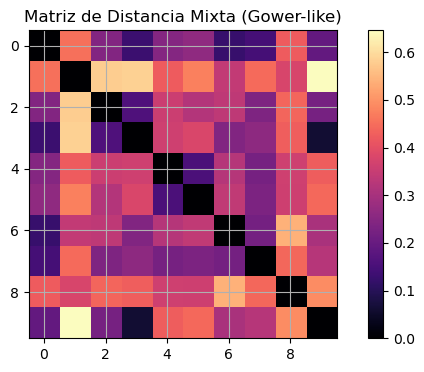

In [38]:
# Visualización opcional para cerrar con broche de oro
plt.imshow(Dmix_df.values, cmap='magma')
plt.title("Matriz de Distancia Mixta (Gower-like)")
plt.colorbar()
plt.show()